# Optimized-Roll Commodities — a quantitative teardown 🔬
### Excess-of-cash Sharpe race · paired block-bootstrap advantage CIs · HAC *t* on the return difference · the era sign-flip · cost & composition-tilt decomposition · a planted-edge synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim is a structural roll-yield edge: optimized-roll (USCI) should out-earn front-month (GSG, DJP) and semi-optimized (DBC) on a higher **excess-of-cash Sharpe**. The job is to race them excess-vs-excess and stress the advantage for significance and era-robustness.

> ⚠️ **Data note.** yfinance **total-return** closes (already net of each fund's expense ratio); every leg taken **excess of BIL**; 190 common months (USCI inception 2010-08 gates the start; PDBC from 2014-11). Numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprint `16935c3b46d8`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from opt_roll import data, strategy as st

BENCH = ["DBC", "GSG", "DJP"]
ERAS = [("deep-contango 2010-2015", "2010-09", "2015-12"),
        ("recovery 2016-2020", "2016-01", "2020-12"),
        ("backwardation 2021-2026", "2021-01", "2026-06")]
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    RETS = data.monthly_returns(PRICES, asof=data.AS_OF)
    EX = st.excess_frame(RETS, cash=data.CASH)
    COMMON = st.common_sample(EX, ["USCI"] + BENCH)
else:
    PRICES = RETS = EX = COMMON = None
print("real tape cached:", HAVE_REAL, "| common months:", (0 if COMMON is None else len(COMMON)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '16935c3b46d8', 'n': 190, 'legs': {'USCI': {'ex': 3.61, 'vol': 14.7, 'sharpe': 0.245, 'tr': 3.95, 'dd': -64.0, 'er': 1.03}, 'DBC': {'ex': 2.34, 'vol': 17.2, 'sharpe': 0.136, 'tr': 2.24, 'dd': -64.8, 'er': 0.85}, 'GSG': {'ex': 1.14, 'vol': 21.3, 'sharpe': 0.053, 'tr': 0.18, 'dd': -78.2, 'er': 0.48}, 'DJP': {'ex': 0.67, 'vol': 16.5, 'sharpe': 0.04, 'tr': 0.66, 'dd': -69.4, 'er': 0.7}}, 'race': {'DBC': {'adv': 0.109, 'lo': -0.13, 'hi': 0.344, 'frac': 0.195, 'diff': 1.26, 't': 0.63}, 'GSG': {'adv': 0.191, 'lo': -0.069, 'hi': 0.433, 'frac': 0.075, 'diff': 2.47, 't': 0.94}, 'DJP': {'adv': 0.204, 'lo': -0.027, 'hi': 0.437, 'frac': 0.045, 'diff': 2.94, 't': 1.67}}, 'eras': ['deep-contango 2010-2015', 'recovery 2016-2020', 'backwardation 2021-2026'], 'era': {'DBC': [(4.95, 1.49, 0.247), (-7.22, -3.04, -0.48), (5.4, 1.75, 0.438)], 'GSG': [(7.49, 1.48, 0.321), (-3.32, -0.82, -0.265), (2.86, 0.76, 0.428)], 'DJP': [(6.91, 2.68, 0.383), (-4.79, -2.13, -0.341), (6.12, 2.01, 0.494)]}, 'costed': {'DBC': (0.094, 1.06, 0.53), 'GSG': (0.175, 2.27, 0.87), 'DJP': (0.197, 2.86, 1.63)}, 'pdbc': {'n': 139, 'adv': 0.101, 'lo': -0.051, 'hi': 0.245, 'diff': 1.31, 't': 0.65}, 'syn': [(0.0, 0.007, -0.079, 0.1, 0.1, 0.14), (3.0, 0.194, 0.109, 0.292, 3.1, 4.27)]}


real tape cached: True | common months: 190


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | USCI excess-of-cash Sharpe **+0.245** vs DBC +0.136 / GSG +0.053 / DJP +0.040 (right sign) — but every return-difference HAC *t* < 2 (best +1.67 vs DJP), every bootstrap Sharpe-adv CI includes 0, and the edge is **significantly negative** in 2016-2020 (USCI−DBC -7.22%/yr, *t* = -3.04). Not era-robust. |
| **Tradability** | `MIRAGE` | Costs are near-irrelevant (buy-and-hold; ER already embedded); net Sharpe adv +0.094/+0.175/+0.197 — CI still through 0. The raw gap is a **regime bet + a lower-energy/lower-vol composition tilt** (USCI vol 14.7% vs GSG 21.3%), not a bankable roll premium. |

> 💡 In plain words: the optimized wrapper landed on the right side of a two-regime coin over this tape, but the coin, not a constant premium, is what you'd be buying.

## 1 · The claim, steelmanned

Collateralised commodity total return decomposes as

$$r^{index}_t \approx \underbrace{r^{spot}_t}_{\text{price}} + \underbrace{y^{roll}_t}_{\text{term structure}} + \underbrace{r^{f}_t}_{\text{T-bill collateral}}.$$

The collateral leg $r^f$ is identical across wrappers, so we net it out by subtracting BIL: every series below is **excess of cash**, leaving $r^{spot}+y^{roll}$. The roll yield $y^{roll}$ is negative in contango (front-month bleeds) and the optimized rule aims to make it less negative (or positive).

- **H₁ (edge exists).** $\text{Sharpe}(\text{USCI}_{ex}) > \text{Sharpe}(\text{bench}_{ex})$, with the paired-bootstrap advantage CI clear of 0 and the monthly return difference $\Delta_t = \text{USCI}_t - \text{bench}_t$ carrying **HAC *t* ≥ 2**.
- **H₂ (durable, not a regime bet).** The advantage holds — same sign — across sub-eras.
- **H₃ (bankable).** It survives realistic costs and isn't merely a lower-beta composition tilt.

The desk's Real bar needs H₁ **and** H₂; Investable needs H₃ too.

## 2 · So what rides on it

If H₁-H₂ held, "just buy the optimized wrapper" would be a free structural upgrade over a front-month index — a rare costless Sharpe gain in a notoriously return-poor asset class. If only H₁ holds (full-sample) but H₂ fails, the wrapper is a **conditional** trade whose payoff depends on the curve regime you can't forecast — worth understanding, not worth a permanent allocation on the roll story alone. Inference is **Newey-West HAC** throughout (monthly index differentials are serially correlated through overlapping roll windows).

## 3 · The protocol

- **Funds.** USCI (optimized), DBC (Optimum Yield, semi-opt), GSG & DJP (front-month), PDBC (optimized, 2014-11+). yfinance total-return monthly closes, as-of 2026-06-30.
- **Excess-of-cash.** Subtract BIL from every leg.
- **Race.** Annualised excess-of-cash Sharpe per leg; the advantage SR(USCI)−SR(bench) with a **paired circular block bootstrap** (block 6 months, 2000 draws, seed 908) 95% CI; HAC mean-*t* (6 lags) on $\Delta_t$.
- **Eras.** deep-contango 2010-2015 · recovery 2016-2020 · backwardation 2021-2026.
- **Costs.** TR already nets ERs; add incremental bid-ask × reconstitution turnover (USCI the wider spread).
- **Control.** `synthetic_world(roll_edge_annual)` plants a tunable constant edge; the null (0) must not fire.

## 4 · The teardown

### 4a · The full-sample race — right sign, no significance

Each leg's excess-of-cash return / vol / Sharpe, then the USCI−bench advantage with its paired-bootstrap 95% CI and the HAC *t* on the monthly difference.

leg    ex-ret%/yr   vol%  Sharpe
USCI        +3.61   14.7  +0.245


DBC         +2.34   17.2  +0.136


GSG         +1.14   21.3  +0.053


DJP         +0.67   16.5  +0.040


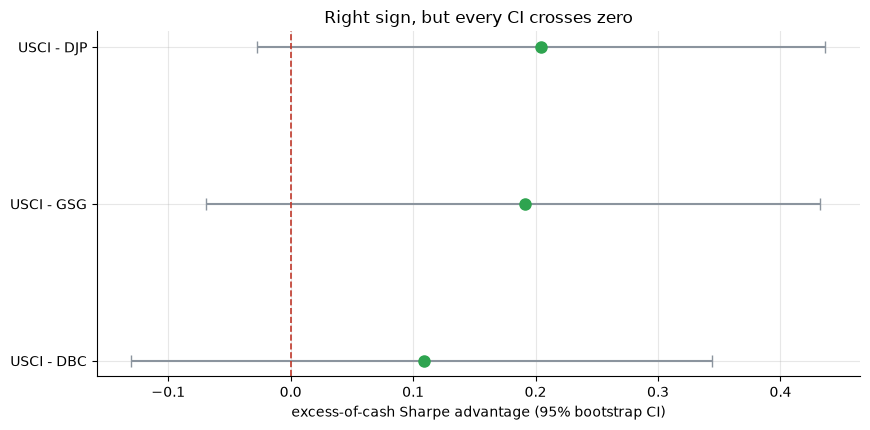

USCI - DBC : Sharpe adv +0.109 CI[-0.130,+0.344]  diff +1.26%/yr (HAC t=+0.63)
USCI - GSG : Sharpe adv +0.191 CI[-0.069,+0.433]  diff +2.47%/yr (HAC t=+0.94)
USCI - DJP : Sharpe adv +0.204 CI[-0.027,+0.437]  diff +2.94%/yr (HAC t=+1.67)


In [2]:
if HAVE_REAL:
    print(f"{'leg':<6s} {'ex-ret%/yr':>10s} {'vol%':>6s} {'Sharpe':>7s}")
    print(f"{'USCI':<6s} {COMMON['USCI'].mean()*1200:>+10.2f} {COMMON['USCI'].std(ddof=1)*np.sqrt(12)*100:>6.1f} {st.annualized_sharpe(COMMON['USCI'].to_numpy()):>+7.3f}")
    rows = []
    for b in BENCH:
        r = st.sharpe_race(EX, 'USCI', b)
        print(f'{b:<6s} {r["ann_ex_bench"]:>+10.2f} {r["vol_bench"]:>6.1f} {r["sharpe_bench"]:>+7.3f}')
        rows.append((b, r['sharpe_adv'], r['adv_ci_lo'], r['adv_ci_hi'], r['diff_ann_pct'], r['t_diff']))
else:
    L = R['legs']
    print(f"{'leg':<6s} {'ex-ret%/yr':>10s} {'vol%':>6s} {'Sharpe':>7s}")
    for f in ['USCI'] + BENCH:
        print(f"{f:<6s} {L[f]['ex']:>+10.2f} {L[f]['vol']:>6.1f} {L[f]['sharpe']:>+7.3f}")
    rows = [(b, R['race'][b]['adv'], R['race'][b]['lo'], R['race'][b]['hi'], R['race'][b]['diff'], R['race'][b]['t']) for b in BENCH]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
y = np.arange(len(rows))
advs = [r[1] for r in rows]; los = [r[1]-r[2] for r in rows]; his = [r[3]-r[1] for r in rows]
ax.errorbar(advs, y, xerr=[los, his], fmt='o', color=GREEN, ecolor=GREY, capsize=4, ms=8)
ax.axvline(0, c=RED, lw=1.2, ls='--')
ax.set_yticks(y); ax.set_yticklabels([f'USCI - {r[0]}' for r in rows])
ax.set_xlabel('excess-of-cash Sharpe advantage (95% bootstrap CI)')
ax.set_title('Right sign, but every CI crosses zero'); plt.tight_layout(); plt.show()
for b, a, lo, hi, d, t in rows: print(f'USCI - {b:<4s}: Sharpe adv {a:+.3f} CI[{lo:+.3f},{hi:+.3f}]  diff {d:+.2f}%/yr (HAC t={t:+.2f})')

> 💡 In plain words: USCI wins all three head-to-heads on Sharpe (advantage +0.11 to +0.20), but **every** confidence interval touches or crosses zero and the strongest return-difference *t* is only **+1.67** (vs the pure front-month DJP). On this sample the edge is directional, not decisive.

### 4b · The era sign-flip — the decisive result

The full-sample win is an average over regimes that disagree. Split it.

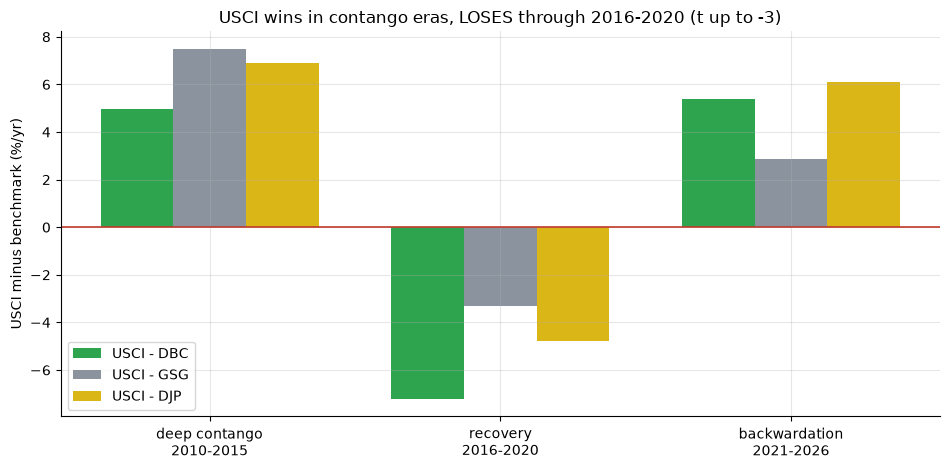

USCI - DBC: ['+5.0%/yr (t=+1.49)', '-7.2%/yr (t=-3.04)', '+5.4%/yr (t=+1.75)']
USCI - GSG: ['+7.5%/yr (t=+1.48)', '-3.3%/yr (t=-0.82)', '+2.9%/yr (t=+0.76)']
USCI - DJP: ['+6.9%/yr (t=+2.68)', '-4.8%/yr (t=-2.13)', '+6.1%/yr (t=+2.01)']


In [3]:
if HAVE_REAL:
    mat = np.array([[e['diff_ann_pct'] for e in st.era_race(EX,'USCI',b,ERAS)] for b in BENCH])
    tmat = np.array([[e['t_diff'] for e in st.era_race(EX,'USCI',b,ERAS)] for b in BENCH])
else:
    mat = np.array([[e[0] for e in R['era'][b]] for b in BENCH])
    tmat = np.array([[e[1] for e in R['era'][b]] for b in BENCH])
eras = ['deep contango\n2010-2015', 'recovery\n2016-2020', 'backwardation\n2021-2026']
x = np.arange(len(eras)); w = .25
fig, ax = plt.subplots(figsize=(9.6, 4.8))
for i, b in enumerate(BENCH):
    ax.bar(x + (i-1)*w, mat[i], w, label=f'USCI - {b}', color=[GREEN,GREY,AMBER][i])
ax.axhline(0, c=RED, lw=1.2); ax.set_xticks(x); ax.set_xticklabels(eras)
ax.set_ylabel('USCI minus benchmark (%/yr)'); ax.legend()
ax.set_title('USCI wins in contango eras, LOSES through 2016-2020 (t up to -3)')
plt.tight_layout(); plt.show()
for i, b in enumerate(BENCH):
    print(f'USCI - {b}:', [f'{mat[i][j]:+.1f}%/yr (t={tmat[i][j]:+.2f})' for j in range(3)])

> 💡 In plain words: across all three benchmarks the pattern is identical — a fat positive edge in the deep-contango 2010-2015 and 2021+ backwardation eras, a **significant negative** edge through the 2016-2020 recovery (USCI−DBC -7.2%/yr at *t* = -3.04; USCI−DJP -4.8%/yr at *t* = -2.13). An edge that goes significantly the *wrong* way for a whole era fails H₂ — it is regime-contingent, not a constant roll premium. **This is why Signal is Weak, not Real.**

### 4c · Costs & composition — why it's a Mirage, not a thin-but-Fragile edge

Total returns already net each ER (USCI 1.03% vs GSG 0.48%). Add an incremental bid-ask charge on reconstitution turnover (USCI wider). Both legs are buy-and-hold, so friction is tiny — the advantage barely moves, meaning costs are **not** the blocker.

In [4]:
if HAVE_REAL:
    for b in BENCH:
        g = st.sharpe_race(EX,'USCI',b); c = st.costed_race(EX,'USCI',b)
        print(f'USCI - {b:<4s}: gross adv {g["sharpe_adv"]:+.3f} -> net {c["sharpe_adv_net"]:+.3f}   '
              f'gross diff {g["diff_ann_pct"]:+.2f}%/yr -> net {c["diff_ann_pct_net"]:+.2f}%/yr (t={c["t_diff_net"]:+.2f})')
    print()
    for f in ['USCI'] + BENCH:
        v = COMMON[f].std(ddof=1)*np.sqrt(12)*100 if f=='USCI' else st.sharpe_race(EX,'USCI',f)['vol_bench']
        print(f'{f}: vol {v:.1f}%/yr, expense ratio {data.EXPENSE_RATIOS[f]:.2f}%')
else:
    for b in BENCH:
        a, d, t = R['costed'][b]; g = R['race'][b]['adv']
        print(f'USCI - {b:<4s}: gross adv {g:+.3f} -> net {a:+.3f}   net diff {d:+.2f}%/yr (t={t:+.2f})')
    print(); 
    for f in ['USCI'] + BENCH: print(f"{f}: vol {R['legs'][f]['vol']:.1f}%/yr, expense ratio {R['legs'][f]['er']:.2f}%")

USCI - DBC : gross adv +0.109 -> net +0.094   gross diff +1.26%/yr -> net +1.06%/yr (t=+0.53)


USCI - GSG : gross adv +0.191 -> net +0.175   gross diff +2.47%/yr -> net +2.27%/yr (t=+0.87)


USCI - DJP : gross adv +0.204 -> net +0.197   gross diff +2.94%/yr -> net +2.86%/yr (t=+1.63)

USCI: vol 14.7%/yr, expense ratio 1.03%


DBC: vol 17.2%/yr, expense ratio 0.85%


GSG: vol 21.3%/yr, expense ratio 0.48%


DJP: vol 16.5%/yr, expense ratio 0.70%


> 💡 In plain words: net of costs the advantage is still +0.09/+0.17/+0.20 Sharpe — essentially unchanged, so friction isn't what defeats it. What does: (i) the sign-flip above, and (ii) **composition** — USCI runs at 14.7% vol vs GSG's 21.3% because it holds far less energy, so a large slice of its Sharpe edge is *lower-beta diversification*, not paid roll yield. A hidden tilt dressed as a roll premium ⇒ **Mirage**.

### 4d · Corroborating cousin — PDBC, same story on a shorter tape

In [5]:
if HAVE_REAL:
    r = st.sharpe_race(EX, 'PDBC', 'GSG')
    print(f"PDBC - GSG (n={r['n']}, {r['start'][:7]}+): Sharpe adv {r['sharpe_adv']:+.3f} "
          f"CI[{r['adv_ci_lo']:+.3f},{r['adv_ci_hi']:+.3f}]  diff {r['diff_ann_pct']:+.2f}%/yr (HAC t={r['t_diff']:+.2f})")
else:
    p = R['pdbc']; print(f"PDBC - GSG (n={p['n']}): Sharpe adv {p['adv']:+.3f} CI[{p['lo']:+.3f},{p['hi']:+.3f}]  diff {p['diff']:+.2f}%/yr (HAC t={p['t']:+.2f})")

PDBC - GSG (n=139, 2014-12+): Sharpe adv +0.101 CI[-0.051,+0.245]  diff +1.31%/yr (HAC t=+0.65)


> 💡 In plain words: the second optimized wrapper (PDBC) also edges front-month GSG — Sharpe adv +0.10 — with a CI through zero and *t* = +0.65. Same direction, same lack of robustness. Consistent, not conclusive.

### 4e · Faithful-engine control — we know the truth here

Planted constant roll edge vs a null. The estimator must recover the knob and stay dark at 0. *(Machinery proof — never market evidence.)*

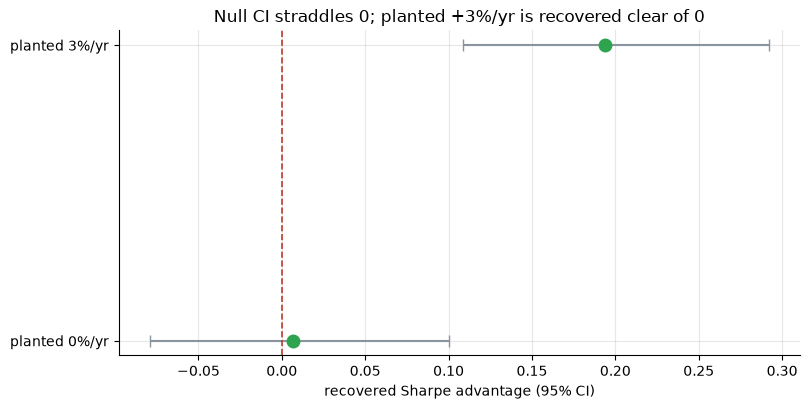

planted +0.0%/yr -> adv +0.007 CI[-0.079,+0.100]  diff +0.10%/yr (HAC t=+0.14)
planted +3.0%/yr -> adv +0.194 CI[+0.109,+0.292]  diff +3.10%/yr (HAC t=+4.27)


In [6]:
res = []
for edge in (0.0, 0.03):
    w = data.synthetic_world(roll_edge_annual=edge, seed=908)
    d = st.synthetic_detect(w)
    res.append((edge*100, d['sharpe_adv'], d['adv_ci_lo'], d['adv_ci_hi'], d['diff_ann_pct'], d['t_diff']))
fig, ax = plt.subplots(figsize=(8.2, 4.2))
y = np.arange(len(res)); advs=[r[1] for r in res]
los=[r[1]-r[2] for r in res]; his=[r[3]-r[1] for r in res]
ax.errorbar(advs, y, xerr=[los,his], fmt='o', color=GREEN, ecolor=GREY, capsize=4, ms=9)
ax.axvline(0, c=RED, lw=1.2, ls='--'); ax.set_yticks(y)
ax.set_yticklabels([f'planted {int(r[0])}%/yr' for r in res])
ax.set_xlabel('recovered Sharpe advantage (95% CI)')
ax.set_title('Null CI straddles 0; planted +3%/yr is recovered clear of 0')
plt.tight_layout(); plt.show()
for e,a,lo,hi,d,t in res: print(f'planted {e:+.1f}%/yr -> adv {a:+.3f} CI[{lo:+.3f},{hi:+.3f}]  diff {d:+.2f}%/yr (HAC t={t:+.2f})')

> 💡 In plain words: the null reads adv +0.007 (CI through 0, *t* = +0.14); a planted **+3%/yr** comes back at diff +3.10%/yr, *t* = +4.27, CI clear of 0. The machinery **would** certify a genuine constant roll edge at this length — so the real-tape verdict is a fact about the tape (regime-flipping), not a lack of power.

## 5 · The verdict

- **Signal `WEAK`** — USCI wins the full-sample excess-of-cash Sharpe race vs all benchmarks (+0.245 vs +0.136/+0.053/+0.040), the right sign, PDBC corroborating — but no return-difference clears HAC *t* ≥ 2 (best +1.67), every bootstrap advantage CI includes 0, and the edge is **significantly negative** in 2016-2020 (−7.2%/yr vs DBC, *t* = -3.04). Fails the era-robustness leg of the Real bar.
- **Tradability `MIRAGE`** — friction is negligible (buy-and-hold; ERs already embedded) so net ≈ gross, yet there's no bankable edge: the advantage could be zero, its sign is regime-contingent, and much of the raw Sharpe gap is a lower-energy/lower-vol **composition tilt**, not a paid roll premium. The roll-yield 'free lunch' is a contango-regime bet.

## 6 · Going further

- **Conditional, not constant.** A curve-state-conditioned allocation (hold optimized only when the aggregate curve is in contango) is the natural follow-up — but that is *timing*, which is [35-contango](../../35-contango/README.md)'s question, not this one.
- **Strip the composition.** Vol-match or energy-match USCI to GSG before racing to isolate the pure roll component from the diversification tilt.
- **Dedup on the desk.** [35-contango](../../35-contango/README.md) times the curve; [794-commodity-carry](../../794-commodity-carry/README.md) sorts single commodities on carry; [661-uso-roll-decay](../../661-uso-roll-decay/README.md) is single-commodity roll decay; [226-crude-seasonality](../../226-crude-seasonality/README.md) a single-commodity calendar effect. This study races **whole packaged wrappers**, always invested.

*Frozen numbers: [`docs/results.md`](../docs/results.md); sources: [`docs/references.md`](../docs/references.md).*